In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

PROJECT_DIR = '/content/drive/MyDrive/esm2-variant-benchmark'

# Check the project folder itself exists
if not os.path.exists(PROJECT_DIR):
    raise FileNotFoundError(
        f'Project folder not found at {PROJECT_DIR}. '
        f'Check that Drive mounted correctly and the path matches your earlier notebooks.'
    )

final_path = f'{PROJECT_DIR}/data/processed/variants_with_all_scores.tsv'

# Check the specific file from WP3 exists before trying to read it
if not os.path.exists(final_path):
    print(f'ERROR: expected file not found at {final_path}')
    print('Checking what IS in data/processed/ instead:')
    processed_dir = f'{PROJECT_DIR}/data/processed'
    if os.path.exists(processed_dir):
        for f in os.listdir(processed_dir):
            print(f'  {f}')
    else:
        print(f'  data/processed/ folder does not exist at all.')
    raise FileNotFoundError('Fix the path above before continuing -- see printed file list.')

df = pd.read_csv(final_path, sep='\t')
print(f'Loaded {len(df)} total rows from {final_path}')
print(f'Columns available: {list(df.columns)}')

required_cols = ['conservation_score', 'esm2_score', 'label']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f'Missing required columns: {missing_cols}. Check WP2/WP3 outputs.')

df = df.dropna(subset=required_cols)
print(f'{len(df)} variants with complete data for modeling.')
print(df['label'].value_counts())


Mounted at /content/drive
Loaded 6498 total rows from /content/drive/MyDrive/esm2-variant-benchmark/data/processed/variants_with_all_scores.tsv
Columns available: ['GeneSymbol', 'uniprot_accession', 'protein_change', 'label', 'ReviewStatus', 'PhenotypeList', 'position', 'conservation_score', 'wt_aa', 'mut_aa', 'esm2_score']
6498 variants with complete data for modeling.
label
1    4385
0    2113
Name: count, dtype: int64


In [4]:
!pip install -q scikit-learn matplotlib

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
print('Ready.')

Ready.


In [5]:
# Stratified 5-fold CV keeps the pathogenic/benign ratio consistent across
# folds, since your classes aren't perfectly balanced. We standardize
# features (mean 0, std 1) since logistic regression is scale-sensitive,
# and conservation_score / esm2_score live on very different scales.
X_conservation = df[['conservation_score']].values
X_esm2 = df[['esm2_score']].values
X_combined = df[['conservation_score', 'esm2_score']].values
y = df['label'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_cv_probs(X, y, cv):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = LogisticRegression(random_state=42)
    probs = cross_val_predict(model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
    return probs

print('Setup complete.')

Setup complete.


In [6]:
# This trains and evaluates each model across 5 folds, so every prediction
# is made on data the model didn't see during training -- avoids overfitting
# inflating your reported performance.
probs_conservation = get_cv_probs(X_conservation, y, cv)
probs_esm2 = get_cv_probs(X_esm2, y, cv)
probs_combined = get_cv_probs(X_combined, y, cv)

print('Cross-validated predictions generated for all three models.')

Cross-validated predictions generated for all three models.


In [7]:
# AUROC: overall ability to rank pathogenic above benign (0.5 = random, 1.0 = perfect)
# AUPRC: more informative than AUROC when classes are imbalanced, since it
# focuses on precision/recall for the positive (pathogenic) class specifically.
results = {
    'Conservation only': probs_conservation,
    'ESM-2 only': probs_esm2,
    'Combined': probs_combined
}

print(f'{"Model":<20} {"AUROC":<10} {"AUPRC":<10}')
print('-' * 40)
for name, probs in results.items():
    auroc = roc_auc_score(y, probs)
    auprc = average_precision_score(y, probs)
    print(f'{name:<20} {auroc:<10.4f} {auprc:<10.4f}')




Model                AUROC      AUPRC     
----------------------------------------
Conservation only    0.7229     0.8151    
ESM-2 only           0.9145     0.9539    
Combined             0.9187     0.9585    


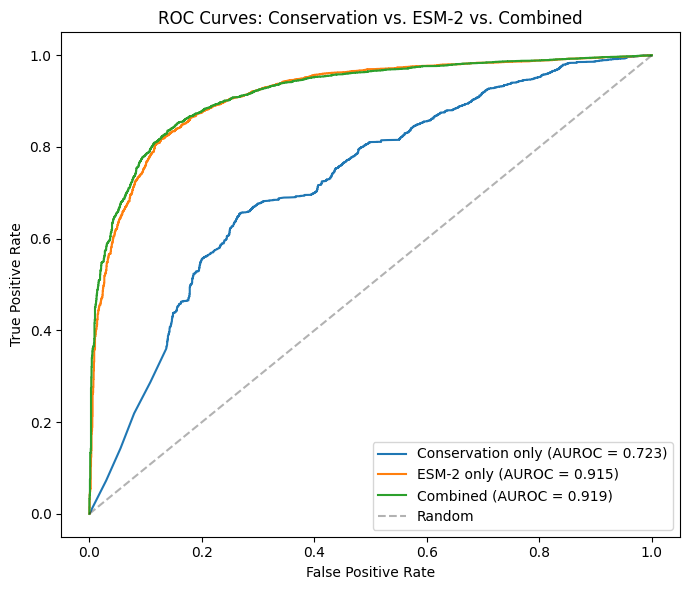

In [9]:
plt.figure(figsize=(7, 6))
for name, probs in results.items():
    fpr, tpr, _ = roc_curve(y, probs)
    auroc = roc_auc_score(y, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUROC = {auroc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Conservation vs. ESM-2 vs. Combined')
plt.legend()
plt.tight_layout()

# Create the output directory if it doesn't exist
output_dir = f'{PROJECT_DIR}/results/figures'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(f'{output_dir}/roc_curves.png', dpi=150)
plt.show()

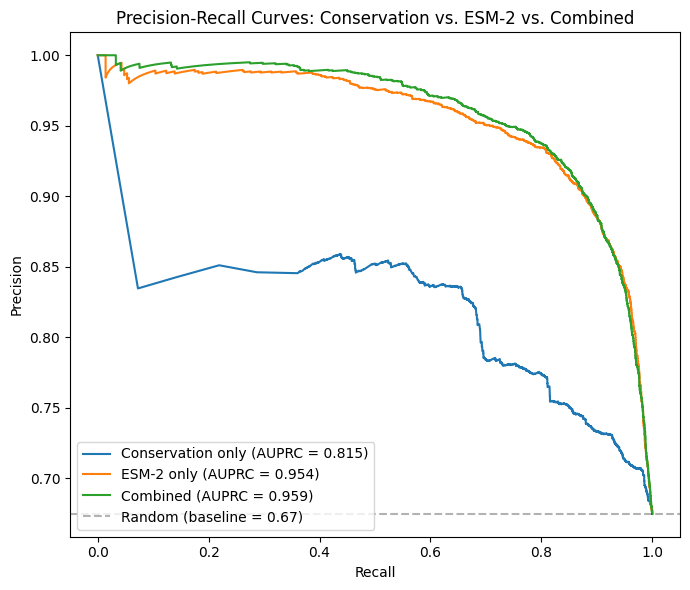

In [10]:
os.makedirs(f'{PROJECT_DIR}/results/figures', exist_ok=True)

plt.figure(figsize=(7, 6))
for name, probs in results.items():
    precision, recall, _ = precision_recall_curve(y, probs)
    auprc = average_precision_score(y, probs)
    plt.plot(recall, precision, label=f'{name} (AUPRC = {auprc:.3f})')

baseline = y.mean()
plt.axhline(baseline, color='k', linestyle='--', alpha=0.3, label=f'Random (baseline = {baseline:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves: Conservation vs. ESM-2 vs. Combined')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/pr_curves.png', dpi=150)
plt.show()

In [11]:
# WP5 (error analysis) needs each variant's predicted probability from each
# model, so we can find where they agree/disagree. Save that here.
df['prob_conservation'] = probs_conservation
df['prob_esm2'] = probs_esm2
df['prob_combined'] = probs_combined

results_table = pd.DataFrame([
    {'model': name, 'auroc': roc_auc_score(y, probs), 'auprc': average_precision_score(y, probs)}
    for name, probs in results.items()
])

os.makedirs(f'{PROJECT_DIR}/results/tables', exist_ok=True)
results_table.to_csv(f'{PROJECT_DIR}/results/tables/model_performance.tsv', sep='\t', index=False)

predictions_path = f'{PROJECT_DIR}/data/processed/variants_with_predictions.tsv'
df.to_csv(predictions_path, sep='\t', index=False)

print('Saved model_performance.tsv and variants_with_predictions.tsv')
results_table

Saved model_performance.tsv and variants_with_predictions.tsv


,model,auroc,auprc
0,Conservation only,0.722895,0.815107
1,ESM-2 only,0.914546,0.953852
2,Combined,0.918663,0.958529
